<a href="https://colab.research.google.com/github/Dhrupad-05/Projects/blob/main/Sentiment_Analysis_of_Movie_Reviews_using_SVM%2C_Logistic_Regression%2C_and_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Movie Reviews using SVM, Logistic Regression, and Naive Bayes

**Overview**

In [ ]:
#IMport Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP and preprocessing
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ML models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import os
import glob

print(" All libraries imported successfully")

 All libraries imported successfully


##  Dataset Overview and Loading

In [ ]:
import tarfile
import os

file_path = "/content/aclImdb_v1 (1).tar.gz"

print(f"1. File exists: {os.path.exists(file_path)}")
print(f"2. File size: {os.path.getsize(file_path) / 1024 / 1024:.1f} MB")

try:
    with tarfile.open(file_path, 'r:gz') as tar:
        print(f"3. ✅ File is valid tar.gz")
        print(f"4. Contains {len(tar.getmembers())} files")
except Exception as e:
    print(f"3. ❌ File is corrupted: {str(e)[:100]}")
    print(f"4. Download fresh copy using FASTEST FIX above")

1. File exists: True
2. File size: 80.2 MB
3. ✅ File is valid tar.gz
4. Contains 100019 files


In [ ]:
# Function to load data from directory structure
def load_imdb_data(base_path, max_samples=5000):
    texts = []
    labels = []

    # Load positive reviews
    pos_files = glob.glob(os.path.join(base_path, 'pos/*.txt'))[:max_samples//2]
    for file_path in pos_files:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            texts.append(f.read())
            labels.append(1)  # Positive

    # Load negative reviews
    neg_files = glob.glob(os.path.join(base_path, 'neg/*.txt'))[:max_samples//2]
    for file_path in neg_files:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            texts.append(f.read())
            labels.append(0)  # Negative

    return texts, labels

# Load training data
train_path = '/tmp/aclImdb/train'
texts, labels = load_imdb_data(train_path, max_samples=5000)

# Create DataFrame
df = pd.DataFrame({'review': texts, 'sentiment': labels})

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

Dataset Shape: (5000, 2)

First 3 rows:
                                              review  sentiment
0  Rohinton Mistry's multi-layered novel seemed i...          1
1  The movie "MacArthur" begins and ends at Gen. ...          1
2  First of all, when people hear 'GUY RITCHIE', ...          1

Data Types:
review       object
sentiment     int64
dtype: object

Missing Values:
review       0
sentiment    0
dtype: int64


### Dataset Description

**IMDB Movie Reviews Dataset:**
- **Source:** Large Movie Review Dataset (IMDB)
- **Samples:** 5,000 reviews (2,500 positive, 2,500 negative)
- **Label Distribution:** Binary classification (Positive=1, Negative=0)
- **Review Length:** Variable (short to very long)

**Columns:**
- `review`: Text of the movie review
- `sentiment`: Label (1=Positive, 0=Negative)

In [11]:
# Dataset statistics
print("\n=== DATASET STATISTICS ===")
print(f"Total Samples: {len(df)}")
print(f"Positive Reviews: {(df['sentiment']==1).sum()}")
print(f"Negative Reviews: {(df['sentiment']==0).sum()}")
print(f"\nSample Positive Review (truncated):")
print(df[df['sentiment']==1]['review'].iloc[0][:300] + "...")
print(f"\nSample Negative Review (truncated):")
print(df[df['sentiment']==0]['review'].iloc[0][:300] + "...")


=== DATASET STATISTICS ===
Total Samples: 5000
Positive Reviews: 2500
Negative Reviews: 2500

Sample Positive Review (truncated):
Rohinton Mistry's multi-layered novel seemed impossible to adapt for the screen but the resulting movie is filled with passion, emotion, humour and pathos. The story is somewhat slow-moving but there is always something on the screen to captivate the audience. The movie perfectly catches a particula...

Sample Negative Review (truncated):
This movie is a bad memory from my childhood. This is one of those movies that they show kids on a rainy day at school when you can't go out for recess, and you'd rather be watching anything, ANYTHING else. At least that's what it was like when I was in elementary school. I just remember HATING this...


##  Data Preprocessing

In [14]:
def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline:
    1. Remove HTML tags
    2. Convert to lowercase
    3. Remove URLs and email addresses
    4. Remove special characters and punctuation
    5. Remove extra whitespace
    """
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Apply preprocessing
print("Preprocessing reviews...")
df['review_cleaned'] = df['review'].apply(preprocess_text)
print("Preprocessing complete")

# Show before and after
print("\n=== PREPROCESSING EXAMPLE ===")
print(f"Before: {df['review'].iloc[0][:200]}")
print(f"\nAfter: {df['review_cleaned'].iloc[0][:200]}")

Preprocessing reviews...
Preprocessing complete

=== PREPROCESSING EXAMPLE ===
Before: Rohinton Mistry's multi-layered novel seemed impossible to adapt for the screen but the resulting movie is filled with passion, emotion, humour and pathos. The story is somewhat slow-moving but there 

After: rohinton mistrys multilayered novel seemed impossible to adapt for the screen but the resulting movie is filled with passion emotion humour and pathos the story is somewhat slowmoving but there is alw


In [16]:
import nltk
nltk.download('punkt_tab', quiet=True)

def advanced_preprocessing(text):
    """
    Advanced preprocessing with stopword removal and lemmatization
    """
    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

# Apply advanced preprocessing (optional - can skip if processing time is long)
print("Applying advanced preprocessing (stopword removal + lemmatization)...")
df['review_processed'] = df['review_cleaned'].apply(advanced_preprocessing)
print("✓ Advanced preprocessing complete")

print(f"\nProcessed review sample:")
print(df['review_processed'].iloc[0][:300])

Applying advanced preprocessing (stopword removal + lemmatization)...
✓ Advanced preprocessing complete

Processed review sample:
rohinton mistrys multilayered novel seemed impossible adapt screen resulting movie filled passion emotion humour pathos story somewhat slowmoving always something screen captivate audience movie perfectly catch particular time place pinpoint accuracy actor indian known western audience joy behold es


##  Exploratory Data Analysis (EDA)

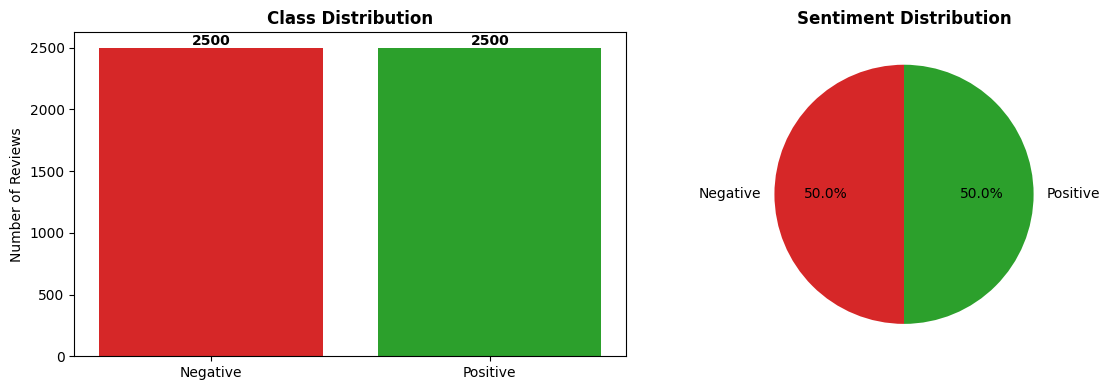

Class Distribution:
sentiment
1    2500
0    2500
Name: count, dtype: int64

Balance: 1.00 (very balanced)


In [17]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
sentiment_counts = df['sentiment'].value_counts()
axes[0].bar(['Negative', 'Positive'], sentiment_counts.values, color=['#d62728', '#2ca02c'])
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=['Negative', 'Positive'], autopct='%1.1f%%',
            colors=['#d62728', '#2ca02c'], startangle=90)
axes[1].set_title('Sentiment Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class Distribution:\n{sentiment_counts}")
print(f"\nBalance: {sentiment_counts[1] / sentiment_counts[0]:.2f} (very balanced)")